In [1]:
#Mount Google Drive (Sel 1)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Import library (Sel 2)
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
#Path dataset (Sel 3)
dataset_path = "/content/drive/MyDrive/CNN_Sampah_UAS_Kecebut/archive/dataset-resized"

In [4]:
#Cek kelas dataset (Sel 4)
classes = os.listdir(dataset_path)

print("Jumlah kelas:", len(classes))
print("Daftar kelas:", classes)

Jumlah kelas: 6
Daftar kelas: ['trash', 'plastic', 'cardboard', 'paper', 'metal', 'glass']


In [5]:
#Import dan tampilkan dataset (Sel 4.5)
import os

print(os.listdir('/content/drive/MyDrive/CNN_Sampah_UAS_Kecebut/archive/dataset-resized'))

['trash', 'plastic', 'cardboard', 'paper', 'metal', 'glass']


In [6]:
#Hitung jumlah gambar tiap kelas (Sel 5)
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    total = len(os.listdir(folder))
    print(f"{cls}: {total} gambar")

trash: 137 gambar
plastic: 482 gambar
cardboard: 403 gambar
paper: 594 gambar
metal: 410 gambar
glass: 501 gambar


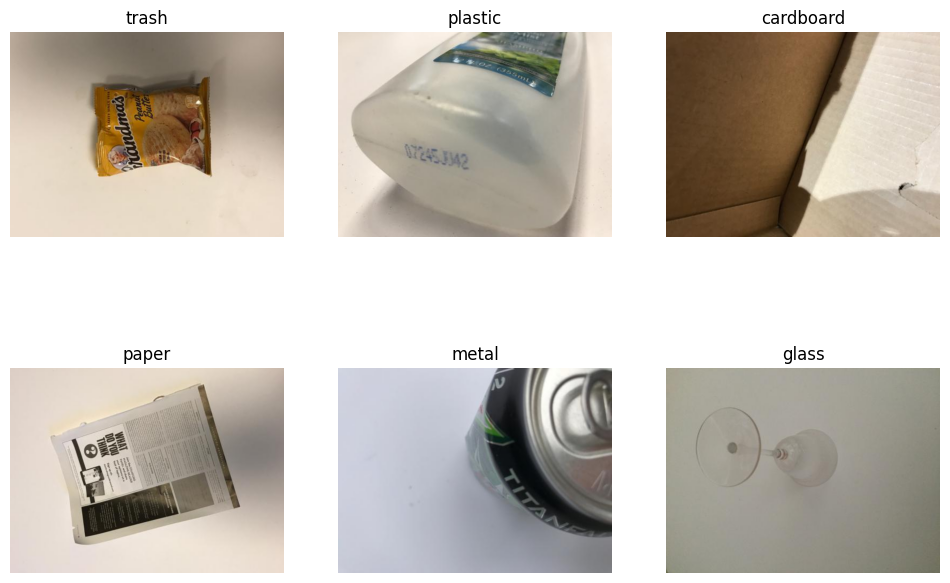

In [7]:
#Tampilkan contoh gambar (Sel 6)
fig, axes = plt.subplots(2, 3, figsize=(12,8))

for ax, cls in zip(axes.ravel(), classes):

    folder = os.path.join(dataset_path, cls)

    image_name = os.listdir(folder)[0]

    image_path = os.path.join(folder, image_name)

    img = Image.open(image_path)

    ax.imshow(img)

    ax.set_title(cls)

    ax.axis("off")

plt.show()

In [8]:
# Hasil Eksplorasi Dataset (Sel 7)

##Dataset terdiri dari 6 kelas:
#- Cardboard
#- Glass
#- Metal
#- Paper
#- Plastic
#- Trash

##Dataset berhasil dibaca dan siap untuk tahap preprocessing.

print("sudah berhasil")

sudah berhasil


In [49]:
#Cek ukuran gambar (Sel 7.5)
sample_class = classes[0]

sample_folder = os.path.join(dataset_path, sample_class)

sample_image = os.listdir(sample_folder)[0]

img = Image.open(os.path.join(sample_folder, sample_image))

print("Ukuran gambar:", img.size)

Ukuran gambar: (512, 384)


In [10]:
#Import TensorFlow (Sel 8)
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [38]:
#Tentukan ukuran gambar (Sel 9)
IMG_HEIGHT = 128
IMG_WIDTH = 128

BATCH_SIZE = 32

In [39]:
#Membuat data generator (Sel 10)
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [40]:
#Membuat data training (Sel 11)
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

Found 2024 images belonging to 6 classes.


In [41]:
#Membuat data validation (Sel 12)
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 503 images belonging to 6 classes.


In [42]:
#Cek hasil split (Sel 13)
print("Jumlah data training:", train_generator.samples)

print("Jumlah data validation:", validation_generator.samples)

Jumlah data training: 2024
Jumlah data validation: 503


In [43]:
#Lihat mapping kelas (Sel 14)
print(train_generator.class_indices)

{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


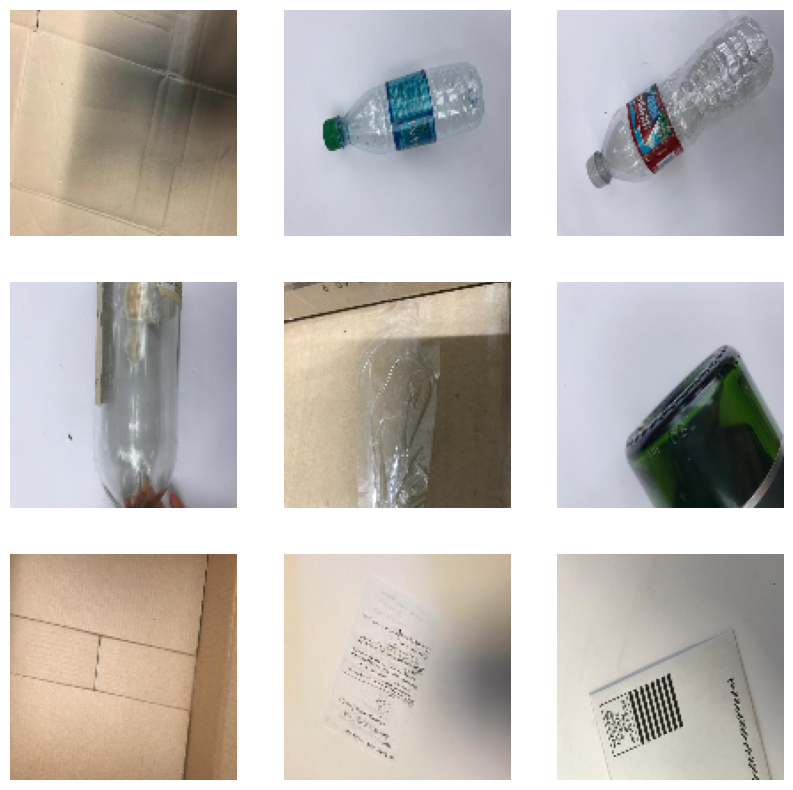

In [44]:
#Tampilkan batch yang sudah diproses (Sel 15)
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(images[i])

    plt.axis("off")

plt.show()

In [45]:
#Import layer CNN (Sel 16)
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

In [46]:
#Membuat arsitektur CNN (Sel 17)
model = Sequential([

    Conv2D(16, (3,3), activation='relu',
           input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(64, activation='relu'),

    Dense(6, activation='softmax')

])

In [47]:
#Compile model (Sel 18)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [48]:
#Lihat ringkasan model (Sel 19)
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     1,843,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,848,742 (7.05 MB)

 Trainable params: 1,848,742 (7.05 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
#Training model (Sel 20)
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 162ms/step - accuracy: 0.8370 - loss: 0.4986 - val_accuracy: 0.4871 - val_loss: 1.6868
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 153ms/step - accuracy: 0.8755 - loss: 0.3903 - val_accuracy: 0.4732 - val_loss: 1.5887
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.9205 - loss: 0.2760 - val_accuracy: 0.4692 - val_loss: 1.8188
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.9452 - loss: 0.2072 - val_accuracy: 0.4950 - val_loss: 1.8494
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.9605 - loss: 0.1469 - val_accuracy: 0.4453 - val_loss: 2.2706
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9664 - loss: 0.1263 - val_accuracy: 0.4930 - val_loss: 2.1135
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 159ms/step - accuracy: 0.9620 - loss: 0.1387 - val_accuracy: 0.4851 - val_loss: 2.3556
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 157ms/step - accuracy: 0.9748 - loss: 0.0978 - val_accur

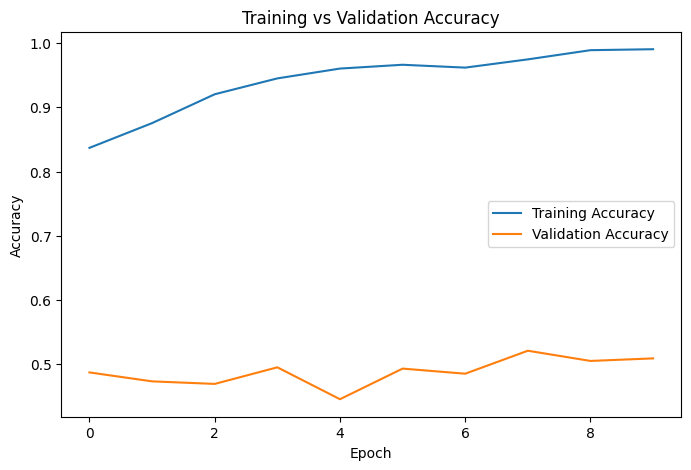

In [53]:
#Grafik accuracy (Sel 21)
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('Training vs Validation Accuracy')

plt.legend()

plt.show()

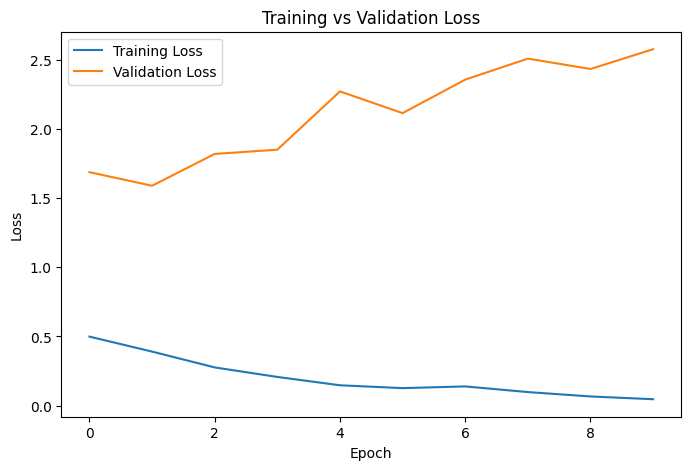

In [54]:
#Grafik loss (Sel 22)
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Training vs Validation Loss')

plt.legend()

plt.show()

In [55]:
#Prediksi data validation (Sel 23)
import numpy as np

validation_generator.reset()

predictions = model.predict(validation_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = validation_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


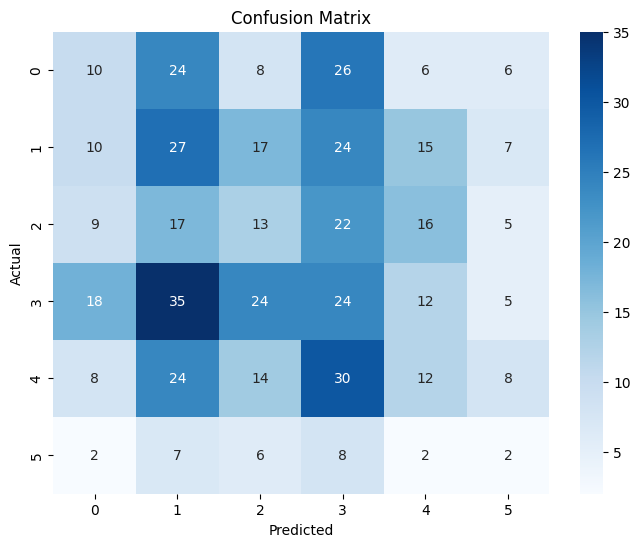

In [57]:
#Confusion matrix (Sel 24)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [58]:
#Classification report (Sel 25)
from sklearn.metrics import classification_report

class_names = list(train_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.18      0.12      0.15        80
       glass       0.20      0.27      0.23       100
       metal       0.16      0.16      0.16        82
       paper       0.18      0.20      0.19       118
     plastic       0.19      0.12      0.15        96
       trash       0.06      0.07      0.07        27

    accuracy                           0.17       503
   macro avg       0.16      0.16      0.16       503
weighted avg       0.18      0.17      0.17       503



In [60]:
#Generator evaluasi baru (Sel 26)
test_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 503 images belonging to 6 classes.


In [61]:
#Prediksi ulang (Sel 27)
predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = test_generator.classes

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 136ms/step


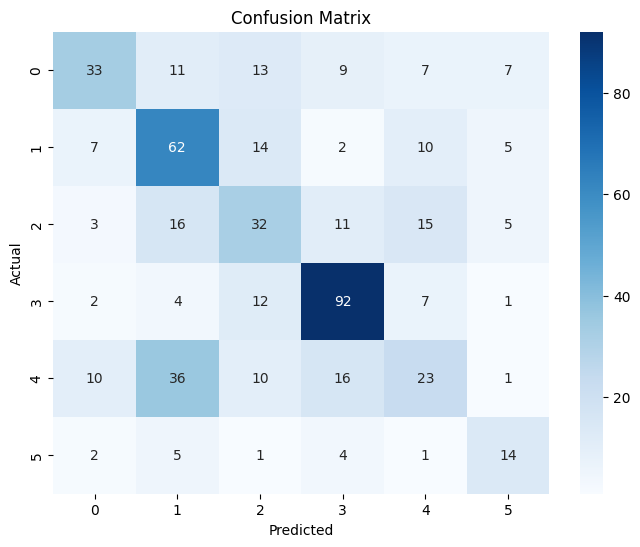

In [62]:
#Confusion matrix baru (Sel 28)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [63]:
#Classification report baru (Sel 29)
from sklearn.metrics import classification_report

class_names = list(test_generator.class_indices.keys())

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   cardboard       0.58      0.41      0.48        80
       glass       0.46      0.62      0.53       100
       metal       0.39      0.39      0.39        82
       paper       0.69      0.78      0.73       118
     plastic       0.37      0.24      0.29        96
       trash       0.42      0.52      0.47        27

    accuracy                           0.51       503
   macro avg       0.48      0.49      0.48       503
weighted avg       0.50      0.51      0.50       503



In [66]:
#Upload gambar baru (Sel 30)
from google.colab import files

uploaded = files.upload()

Saving Screenshot 2026-06-19 173113.png to Screenshot 2026-06-19 173113.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediksi: plastic


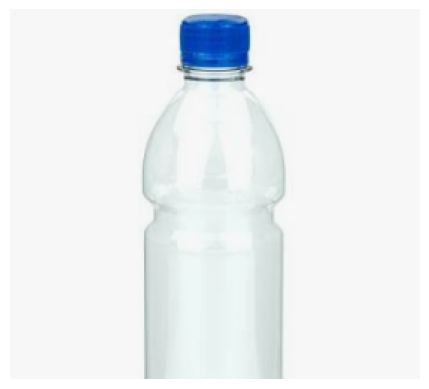

In [67]:
#Prediksi gambar (Sel 31)
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(
    img_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_names = list(test_generator.class_indices.keys())

print("Prediksi:", class_names[predicted_class])

plt.imshow(image.load_img(img_path))
plt.axis("off")
plt.show()